# PyTorch Week 1 — the capstone, reborn in autograd
**Rule of this notebook: PREDICT BEFORE RUN.** Every code cell has a `# PREDICT:` line —
write/say your expected output *before* executing. A wrong prediction = today's re-teach target.

The mission: retrain the hand-built gradient-descent capstone `temp = w·load + b`
(data `[1,2,3] → [40,55,70]`, true fit `w=15, b=25`) — but let **autograd** compute the
gradients you once derived by hand. If both layers agree on the numbers, you own both layers.

## 1 · Tensors — the telemetry container
A tensor is just an n-dim array that *remembers how it was computed* (when asked to).
NVMe hook: a tensor is the payload; `requires_grad` is like enabling latency tracking on a
command — same data, plus bookkeeping for the journey.

In [1]:
import torch

load = torch.tensor([1.0, 2.0, 3.0])   # the capstone's loads
temp = torch.tensor([40.0, 55.0, 70.0])  # observed temps

# PREDICT: what shape does `load` have, and what dtype?
print(load.shape, load.dtype)

torch.Size([3]) torch.float32


In [2]:
# PREDICT: what does load * 15 + 25 print? (you know this line by heart)
print(load * 15 + 25)

tensor([40., 55., 70.])


## 2 · Autograd — the chain rule, automated
You once derived `∂L/∂w = (2/n)·Σ(P−T)·load` by hand. Autograd builds that same derivative
by recording every op on the tensor and replaying the chain rule backwards. Your hand-math
was the proof; autograd is the machine.

In [3]:
w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

P = w * load + b               # prediction (w=0,b=0 → all zeros)
L = torch.mean((P - temp)**2)  # MSE loss

# PREDICT: L = mean of (40², 55², 70²) = ?  (hand-compute: (1600+3025+4900)/3)
print(L.item())

3175.0


In [4]:
L.backward()   # <-- the chain rule runs backwards through the graph

# PREDICT: hand-compute the gradients at w=0, b=0 with YOUR formula:
#   dL/dw = (2/3)·Σ(P−T)·x = (2/3)·[(0−40)·1 + (0−55)·2 + (0−70)·3]
#   dL/db = (2/3)·Σ(P−T)  = (2/3)·[−40 − 55 − 70]
# write both numbers down BEFORE running.
print(w.grad.item(), b.grad.item())

-240.0 -110.0


## 3 · The training loop — your capstone, 12 lines
Same bowl, same rolling ball. Verified checkpoints from the hand-built version:
**iter 180 → w≈15.08, b≈24.81 · iter 500 → exactly (15.0, 25.0)**.

In [5]:
w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
lr = 0.1

for i in range(1, 501):
    P = w * load + b
    L = torch.mean((P - temp)**2)
    L.backward()
    with torch.no_grad():          # step the knobs; don't record the step itself
        w -= lr * w.grad
        b -= lr * b.grad
        w.grad.zero_(); b.grad.zero_()   # C-brain note: grads ACCUMULATE unless cleared
    if i in (60, 180, 500):
        print(f"iter {i:3d}  w={w.item():.4f}  b={b.item():.4f}  loss={L.item():.6f}")

# PREDICT before running: what (w, b) should iter 500 print?

iter  60  w=16.5751  b=21.4193  loss=1.931005
iter 180  w=15.0850  b=24.8069  loss=0.005617
iter 500  w=15.0000  b=24.9999  loss=0.000000


## 4 · See it — the fitted line through the capstone points

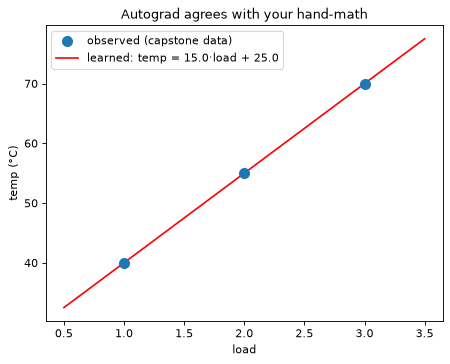

In [6]:
import matplotlib.pyplot as plt
xs = torch.linspace(0.5, 3.5, 50)
with torch.no_grad():
    ys = w * xs + b
plt.scatter(load, temp, s=80, zorder=3, label="observed (capstone data)")
plt.plot(xs, ys, 'r', label=f"learned: temp = {w.item():.1f}·load + {b.item():.1f}")
plt.xlabel("load"); plt.ylabel("temp (°C)"); plt.legend(); plt.title("Autograd agrees with your hand-math")
plt.show()

## 5 · Divergence demo — the fix becomes the failure
Your capstone story: too-big η overshoots to a steeper wall, the gradient grows, and the
correction compounds exponentially. Same physics here.

**PREDICT: with lr = 0.7, does the loss shrink or explode?** Then run.

In [7]:
w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
for i in range(1, 13):
    P = w * load + b
    L = torch.mean((P - temp)**2)
    L.backward()
    with torch.no_grad():
        w -= 0.7 * w.grad; b -= 0.7 * b.grad
        w.grad.zero_(); b.grad.zero_()
    print(f"iter {i:2d}  loss={L.item():.1f}")

iter  1  loss=3175.0
iter  2  loss=143770.0
iter  3  loss=6578715.5
iter  4  loss=301080800.0
iter  5  loss=13779266560.0
iter  6  loss=630622060544.0
iter  7  loss=28861062447104.0
iter  8  loss=1320855854383104.0
iter  9  loss=60450311776501760.0
iter 10  loss=2766569992211136512.0
iter 11  loss=126614859630870790144.0
iter 12  loss=5794657228597911093248.0


## Teach-back (say it out loud, NVMe terms welcome)
1. What did `L.backward()` compute, and which rule from your Foundation sessions is it running?
2. Why must `w.grad` be zeroed every iteration — what silently goes wrong if you don't?
3. `torch.no_grad()` wraps the update step. Why must the step itself stay OFF the tape?

When all three are fluent → tick the Week-1 deliverable box in
`docs/2026-07-25_campusx-m2-plan.md` and advance the ledger.